# 08 - Desperation check (final-shot displacement by how the rally ended)

**Input:** `data/processed/strokes_all.csv`, `data/processed/player_clusters_W.csv`, `data/raw/match.csv`
**What it does:** women's singles. Takes each rally's final stroke (which carries `win_reason`) and compares final-stroke displacement across ending types (own placement winner vs the various forced-opponent-error types), and as a broad own-winner vs forced-error split.
**Output:** `output/final_shot_by_reason.csv`, `output/final_shot_by_reason.png`

Analysis type: descriptive verification.

In [1]:
## --- path bootstrap: run from the repo root no matter where this is launched ---
## nbconvert and some editors set the working directory to the notebook's own
## folder. Walk up until we find the repo root (the folder containing data/),
## chdir there so relative data paths resolve, and put code/ on sys.path so the
## shared modules (utils.py, shot_translations.py) import cleanly.
import os, sys
_d = os.getcwd()
for _ in range(5):
    if os.path.isdir(os.path.join(_d, "data")):
        break
    _d = os.path.dirname(_d)
os.chdir(_d)
if os.path.join(_d, "code") not in sys.path:
    sys.path.insert(0, os.path.join(_d, "code"))
print("working directory:", os.getcwd())

working directory: /Users/aakankshvaidya/Desktop/qss20_final_project


In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import utils

In [3]:
## CONFIG
PROC_DIR = utils.PROC_DIR
OUT_DIR = utils.OUT_DIR
os.makedirs(OUT_DIR, exist_ok=True)
RESTRICT_TO_WOMENS = True

## win_reason (winner's perspective). 落地致勝 = own winning shot; others = opponent error.
WIN_REASON_MAP = {
    "落地致勝": "own winner (placement)",
    "對手出界": "forced error: opponent out",
    "對手掛網": "forced error: opponent netted",
    "對手未過網": "forced error: opponent short",
    "對手落點判斷失誤": "forced error: opponent misjudged",
    "對手犯規": "opponent foul",
}

## Load, resolve names, restrict to women's

In [4]:
strokes = utils.load_strokes()
matches = utils.load_matches()
strokes = utils.map_player_names(strokes, matches)
if RESTRICT_TO_WOMENS:
    strokes = utils.restrict_to_womens(strokes, how="clusters")
print("strokes:", len(strokes))

map_player_names: rows before merge = 52356, after = 52356
map_player_names: unique players resolved = 35
restrict_to_womens: rows before filter = 52356, after = 22503
strokes: 22503


## Final stroke of each rally (carries win_reason)

In [5]:
final_strokes = strokes[strokes["win_reason"].notna()].copy()
print("rallies with an identifiable winning stroke:", len(final_strokes))
final_strokes["ending_type"] = final_strokes["win_reason"].map(WIN_REASON_MAP).fillna("other")
final_strokes["ending_group"] = np.where(
    final_strokes["win_reason"] == "落地致勝", "own winner (placement)", "forced opponent error"
)

rallies with an identifiable winning stroke: 2181


## Displacement by detailed ending type

In [6]:
valid = final_strokes.dropna(subset=["displacement"])
by_reason = valid.groupby("ending_type")["displacement"].agg(
    ["mean", "median", "std", "count"]).round(1).sort_values("mean", ascending=False)
print(by_reason)
by_reason.to_csv(os.path.join(OUT_DIR, "final_shot_by_reason.csv"))

                                   mean  median    std  count
ending_type                                                  
forced error: opponent out        232.8   222.6   98.1    681
forced error: opponent short      226.3   202.7  113.7    216
own winner (placement)            208.1   205.0   91.1    679
forced error: opponent misjudged  199.0   206.9   88.4     90
forced error: opponent netted     175.4   172.0   66.0    511
opponent foul                     143.7   124.9  123.2      4


## Own winner vs forced error (broad split)

In [7]:
by_group = valid.groupby("ending_group")["displacement"].agg(["mean", "median", "count"]).round(1)
print(by_group)
own = valid[valid["ending_group"] == "own winner (placement)"]["displacement"].mean()
forced = valid[valid["ending_group"] == "forced opponent error"]["displacement"].mean()
print(f"own-winner final shots:   {own:.1f}")
print(f"forced-error final shots: {forced:.1f}")
print(f"difference: {own - forced:+.1f}")

                         mean  median  count
ending_group                                
forced opponent error   210.1   196.0   1502
own winner (placement)  208.1   205.0    679
own-winner final shots:   208.1
forced-error final shots: 210.1
difference: -2.0


## Figure

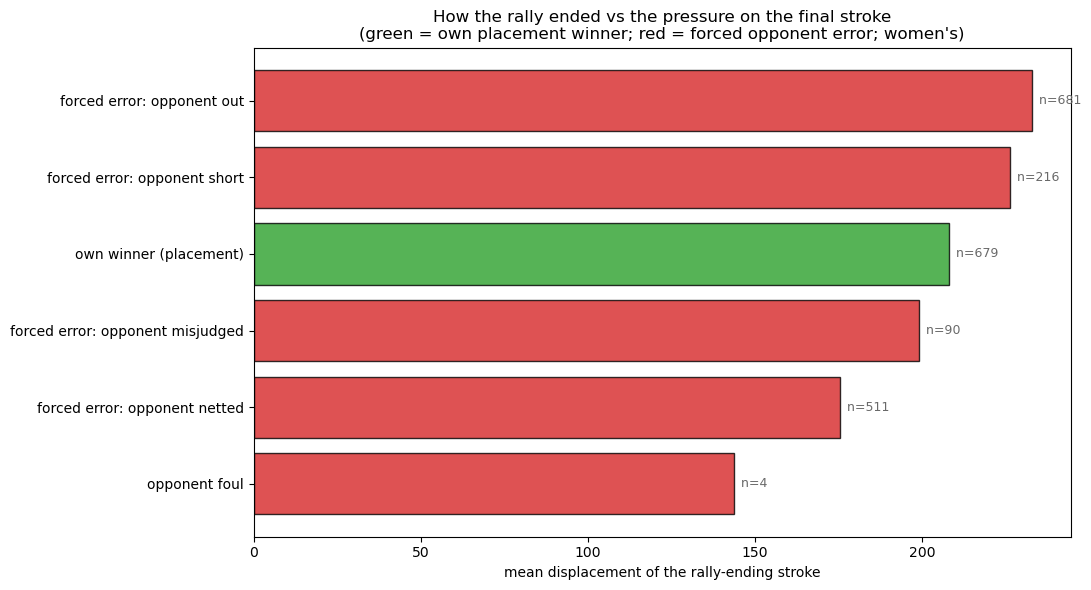

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
by_reason_sorted = by_reason.sort_values("mean")
colors = ["#2ca02c" if "own winner" in idx else "#d62728" for idx in by_reason_sorted.index]
ax.barh(by_reason_sorted.index, by_reason_sorted["mean"], color=colors, alpha=0.8, edgecolor="black")
for i, (mean_val, n) in enumerate(zip(by_reason_sorted["mean"], by_reason_sorted["count"])):
    ax.text(mean_val + 1, i, f" n={n}", va="center", fontsize=9, color="dimgray")
ax.set_xlabel("mean displacement of the rally-ending stroke")
ax.set_title("How the rally ended vs the pressure on the final stroke\n(green = own placement winner; red = forced opponent error; women's)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "final_shot_by_reason.png"), dpi=150)
plt.show()